# Part A — Profiling, cleaning, and the data story

In [64]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Task 1
Load the dataset and profile it: print df.info(), df.describe(), and df.shape. Compute and report the percentage of missing values in every column that has any. Immediately after loading, save the loaded DataFrame as a committed offline fallback — df.to_csv("titanic.csv", index=False) — inside /analytics, so your submission can be graded via pd.read_csv("titanic.csv") even if sns.load_dataset(...) cannot reach the internet at grading time. This is the one and only load of the raw dataset; everything below — including the modeling pipeline — works from this same DataFrame or its saved CSV.

In [65]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')
df.to_csv("titanic.csv",index= False)
df.info() # Prints the info of the entire dataset
print(df.shape)   # ← must be an explicit print
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
(891, 15)


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [66]:

# Compute and Report the percentage of missing values in each columns
print("Missing Values:")
missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)


Missing Values:


,Missing_Count
deck,688
age,177
embarked,2
embark_town,2


In [67]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

,Missing Count,Missing Percentage
survived,0,0.00
pclass,0,0.00
sex,0,0.00
age,177,19.87
sibsp,0,0.00
parch,0,0.00
fare,0,0.00
embarked,2,0.22
class,0,0.00
who,0,0.00


# Task 2
Apply missing-value handling per column, following this threshold rule (under 5% missing → drop those rows; 5%–30% missing → impute) — and for any column whose missing rate is so high that imputation would be unreliable, explicitly decide to either drop the column or encode "missing" as its own category, and justify that decision in writing. State the exact percentage you measured for each affected column before choosing its strategy.

"age: 19.87 % → median imputation (5–30 % band); embarked/embark_town: 0.22 % → drop rows (<5 % threshold); deck: 77.22 % → drop column (>50 %, too unreliable to impute)"

In [68]:
df_titanic = df.copy()

# Imputation for age column as it has missing percentage between 5% - 30%
df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median()) # age has missing percentage of 19.87% hence the imputationo fmedian is applied here


# Drop the column entirely since deck column has percentage more than 50 % values
df_titanic = df_titanic.drop(columns=['deck'])


# Drop the embark_town and embarked rows where missing are present for those specific rows as the misisng percentage is below 5% 
df_titanic = df_titanic.dropna(subset=['embarked','embark_town']) # Drop the rows of both embarked and embark_town since the percentage is 0.22 for both of them
df_titanic.info()
df_titanic.shape



<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    str     
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        889 non-null    category
 9   who          889 non-null    str     
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        889 non-null    str     
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 86.1 KB


(889, 14)

# Task 3
Univariate analysis: plot a histogram and a box plot for both age and fare. Using the IQR rule (outliers are points outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]), report how many outliers each column has. Compute mean, median, and mode for fare, and state in writing whether its distribution is right-skewed, left-skewed, or symmetric, referencing the mean/median/mode ordering.

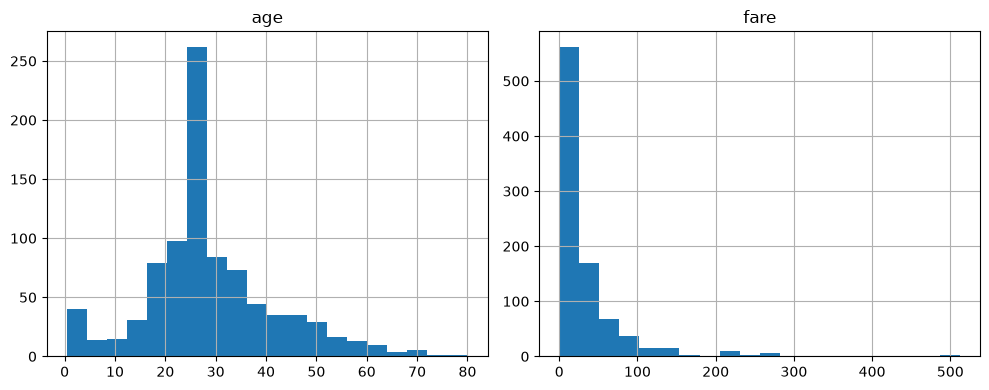

In [69]:
# Plot a histogram plot for both age and fare

import matplotlib.pyplot as plt

df_titanic[['age', 'fare']].hist(bins=20, figsize=(10, 4))
plt.tight_layout()
plt.show()


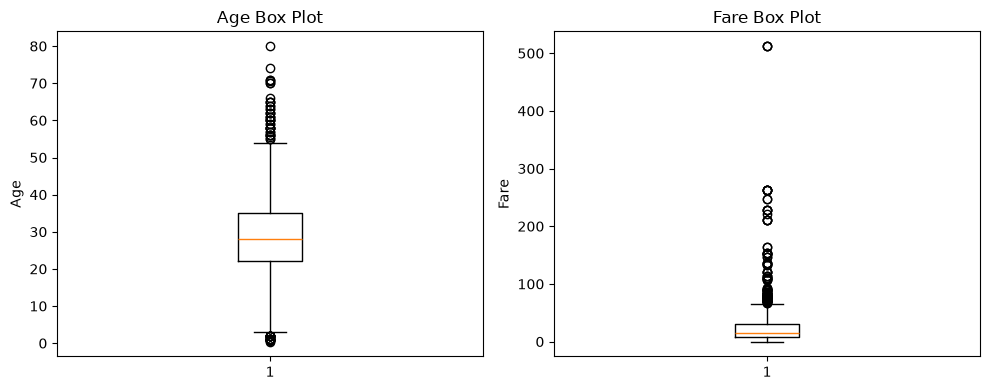

In [70]:
# Plot a box plot for both Age and fare
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df_titanic['age'])
axes[0].set_title("Age Box Plot")
axes[0].set_ylabel("Age")

axes[1].boxplot(df_titanic['fare'])
axes[1].set_title("Fare Box Plot")
axes[1].set_ylabel("Fare")

plt.tight_layout()
plt.show()

In [71]:
#Using the IQR rule (outliers are points outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR])

# Calculating IQR and outliers for age
q1 = df_titanic['age'].quantile(0.25)
q3 = df_titanic['age'].quantile(0.75)

IQR = q3-q1
print(IQR)

lower = q1-(1.5*IQR)
upper = q3+(1.5*IQR)
print(lower, upper)

outliers_age = df_titanic[(df_titanic['age']<lower) | (df_titanic["age"]>upper)]
print("Age outliers:", len(outliers_age))



13.0
2.5 54.5
Age outliers: 65


In [72]:
# Calculating IQR and outliers for fare
q1 = df_titanic['fare'].quantile(0.25)
q3 = df_titanic['fare'].quantile(0.75)

IQR = q3-q1
print(IQR)

lower = q1-(1.5*IQR)
upper = q3+(1.5*IQR)
print(lower, upper)

outliers_fare = df_titanic[(df_titanic['fare']<lower) | (df_titanic["fare"]>upper)]
print("Fare outliers:", len(outliers_fare))

23.1042
-26.7605 65.6563
Fare outliers: 114


In [73]:
#  Compute mean, median, and mode for fare, 
mean_fare = df_titanic['fare'].mean()
median_fare = df_titanic['fare'].median()
mode_fare = df_titanic['fare'].mode()[0]

print("Mean:", mean_fare)
print("Median:", median_fare)
print("Mode:", mode_fare)

if mean_fare > median_fare > mode_fare:
    print("Fare is right-skewed")
elif mean_fare < median_fare < mode_fare:
    print("Fare is left-skewed")
else:
    print("Fare is approximately symmetric")



Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Fare is right-skewed


Conclusion : The Fare distribution is right-skewed because the mean is greater than the median, and the median is greater than the mode (Mean > Median > Mode). This indicates that the distribution has a longer tail toward higher fare values.

# Task 4
Bivariate analysis: using boolean masking (with &/| combinations), compute and report survival rate broken down by (a) sex, (b) pclass, and (c) sex and pclass together. Then compute a correlation matrix restricted to exactly these six columns: survived, pclass, age, sibsp, parch, and fare — the dataset's numeric columns, including survived (0/1-valued) as the natural numeric target. Exclude the boolean-typed columns adult_male and alone from the correlation matrix: they are derived/redundant flags (directly computable from sex/age and from sibsp+parch respectively), not independent measured features. Render the resulting 6×6 matrix as a heatmap using sns.heatmap, with a short written interpretation of the two strongest correlations you observe — defined precisely as the two feature pairs with the largest absolute off-diagonal correlation coefficients (rank all off-diagonal pairs by abs(correlation) and take the top two).

In [74]:
#using boolean masking (with &/| combinations), compute and report survival rate broken down by (a) sex, (b) pclass, and (c) sex and pclass together.
# survival rate for column sex
female_survival_rate = (df_titanic[df_titanic['sex'] == 'female']['survived'].mean()*100)
male_survival_rate = (df_titanic[df_titanic['sex'] == 'male']['survived'].mean()* 100)

print("SURVIVAL RATE BY SEX")
print(f"Female: {female_survival_rate:.2f}%")
print(f"Male: {male_survival_rate:.2f}%")


SURVIVAL RATE BY SEX
Female: 74.04%
Male: 18.89%


In [75]:
df_titanic['pclass'].unique()

array([3, 1, 2])

In [76]:
# (B) Survival Rate by Passenger Class
for pclass in [1, 2, 3]:
    rate = (df_titanic[df_titanic['pclass'] == pclass]['survived'].mean() * 100)
    print(f"Pclass {pclass}: {rate:.2f}%")

Pclass 1: 62.62%
Pclass 2: 47.28%
Pclass 3: 24.24%


In [77]:
# (C) Survival Rate by Sex AND Passenger Class
print("\nSURVIVAL RATE BY SEX & PCLASS")
for sex in ['female', 'male']:
    for pclass in [1, 2, 3]:
        rate = (df_titanic[(df_titanic['sex'] == sex) & (df_titanic['pclass'] == pclass)]['survived'].mean() * 100)
        print(f"{sex.capitalize()} | Pclass {pclass} : "f"{rate:.2f}%")


SURVIVAL RATE BY SEX & PCLASS
Female | Pclass 1 : 96.74%
Female | Pclass 2 : 92.11%
Female | Pclass 3 : 50.00%
Male | Pclass 1 : 36.89%
Male | Pclass 2 : 15.74%
Male | Pclass 3 : 13.54%


In [78]:
#Then compute a correlation matrix restricted to exactly these six columns: 
# survived, pclass, age, sibsp, parch, and fare — the dataset's numeric columns, 
# including survived (0/1-valued) as the natural numeric target. 
# Exclude the boolean-typed columns adult_male and alone from the correlation matrix: 
# they are derived/redundant flags (directly computable from sex/age and from sibsp+parch respectively), not independent measured features. 

In [79]:
# Take the correlated columns
corr_cols =['survived','pclass','age','sibsp','parch','fare']
# Create the correlation matrix
corr_matrix = df_titanic[corr_cols].corr()

# Display correlation values
print("Correlation Matrix")
print(corr_matrix)


Correlation Matrix
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


In [80]:
# Render the resulting 6×6 matrix as a heatmap using sns.heatmap, with a short written interpretation of the two strongest correlations you observe — defined precisely 
# as the two feature pairs with the largest absolute off-diagonal correlation coefficients (rank all off-diagonal pairs by abs(correlation) and take the top two).

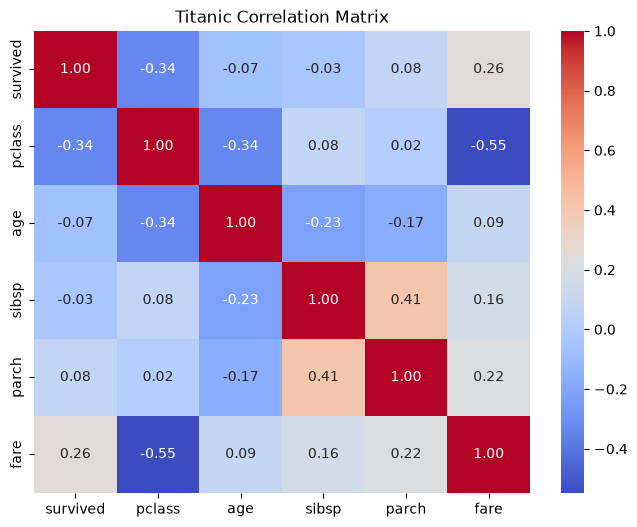

In [81]:
# Rendering as Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Titanic Correlation Matrix')
plt.show()

**# Interpretation of the Strongest correlation fetaures**

The correlation matrix was calculated using the six specified numerical columns: survived, pclass, age, sibsp, parch, and fare.

The strongest correlation was between pclass and fare (r = -0.55). This negative relationship indicates that first-class passengers generally paid higher fares, whereas third-class passengers paid lower fares.

The second strongest correlation was between sibsp and parch (r = 0.41). This positive relationship suggests that passengers traveling with siblings/spouses were also likely to be traveling with parents/children, indicating family travel groups on the Titanic.

# Task 5
Multivariate "data story": produce at least 4 distinct charts (any combination of bar/box/scatter/heatmap/pair-plot) that together build a coherent argument about who was more likely to survive and why. 
Each chart must be accompanied by a 2–4 sentence written interpretation in your README/notebook — a chart with no interpretation does not count.

In [82]:
# **Multivariate Data story **: Instead of looking at one variable (age) or two variables (sex vs survived), you combine multiple variables to answer


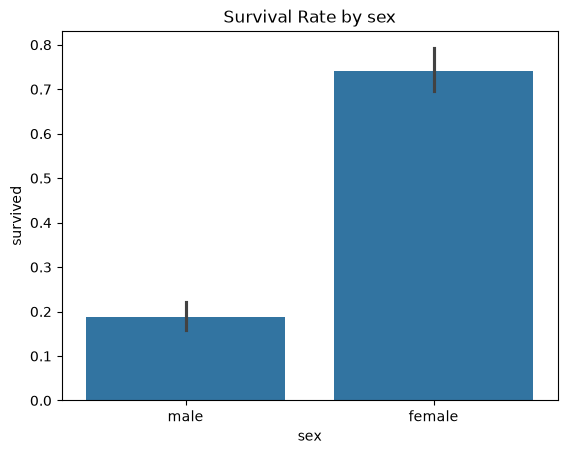

In [83]:
# Chart 1: Survival Rate by Sex (Bar Plot)

sns.barplot(data= df_titanic,x= 'sex',y='survived')
plt.title('Survival Rate by sex')
plt.show()

**Interpretation**

1) Female passengers had a much higher survival rate than male passengers.

2) This suggests that gender played a significant role in survival outcomes.

3) The results support the historical "women and children first" evacuation practice.

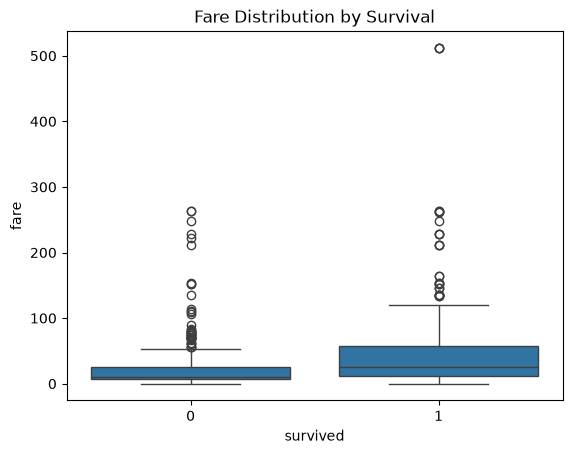

In [84]:
# 2. Box Plot: Fare Distribution by Survival

sns.boxplot(data=df_titanic, x='survived', y='fare')
plt.title('Fare Distribution by Survival')
plt.show()

**Interpretation**

1) Passengers who survived generally paid higher fares than those who did not survive.
2) Higher fares are associated with higher passenger classes.
3) This suggests that wealth and passenger class may have influenced survival chances.


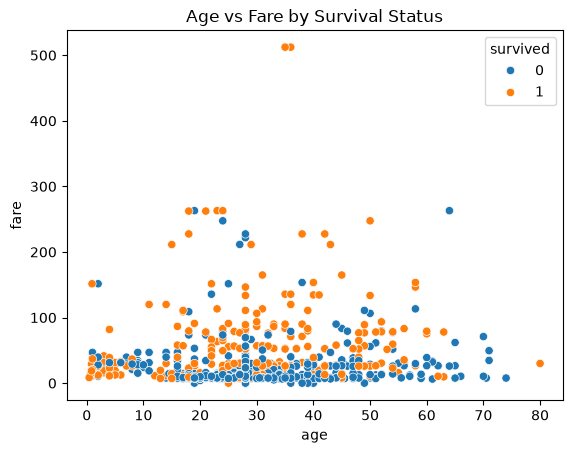

In [85]:
# Scatter Plot: Age vs Fare (Colored by Survival)
sns.scatterplot(data=df_titanic,x='age',y='fare',hue='survived')
plt.title('Age vs Fare by Survival Status')
plt.show()

**Interpretation**

1) Survivors are concentrated more heavily among passengers who paid higher fares.
2) Age alone does not show a strong separation between survivors and non-survivors.
3) Fare appears to be a more influential factor than age.


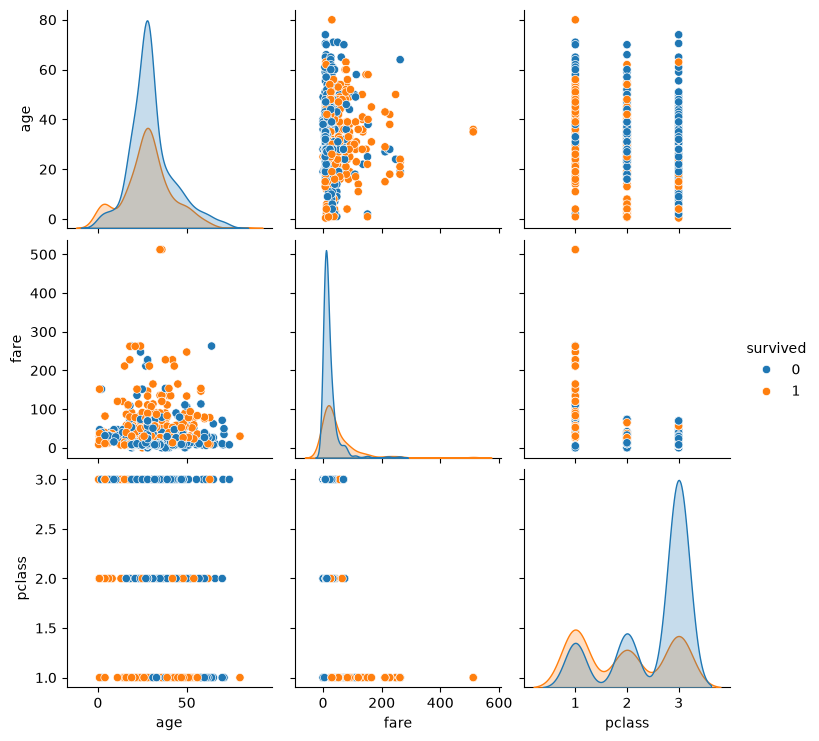

In [86]:
# Pairplot between survived, age, fare, pclass

sns.pairplot(
    df_titanic[['survived','age','fare','pclass']],
    hue='survived'
)
plt.show()

**Interpretation**
1) The pair plot shows the relationships among age, fare, passenger class, and survival status simultaneously. Survivors are more concentrated among passengers who paid higher fares and belonged to higher classes (lower pclass values), indicating that socio-economic status played an important role in survival.

2) There is considerable overlap in the age distributions of survivors and non-survivors, suggesting that age alone was not a strong predictor of survival. Overall, the visualizations indicate that passenger class and fare had a stronger association with survival than age.

# Task 6
As an exploratory check (not yet the modeling pipeline's own preprocessing — that is handled separately in Task 8 below), standardize age and fare using the z-score formula z = (x − mean) / std on the full cleaned DataFrame (you may use StandardScaler or compute it manually). Show a before/after comparison (e.g., a printed summary of means/stds, or overlaid distribution plots) confirming the transformed columns have (approximately) mean 0 and standard deviation 1. This is purely an EDA-stage sanity check; it does not feed into the modeling pipeline, which performs its own train-only scaling.

In [87]:
from sklearn.preprocessing import StandardScaler

# Before Scaling
print("Before Scaling")
print(df_titanic[['age', 'fare']].agg(['mean', 'std']))

# Standardization
scaler = StandardScaler()

df_titanic[['age_z', 'fare_z']] = scaler.fit_transform(
    df_titanic[['age', 'fare']]
)

# After Scaling
print("\nAfter Scaling")
print(df_titanic[['age_z', 'fare_z']].agg(['mean', 'std']))

Before Scaling
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Scaling
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


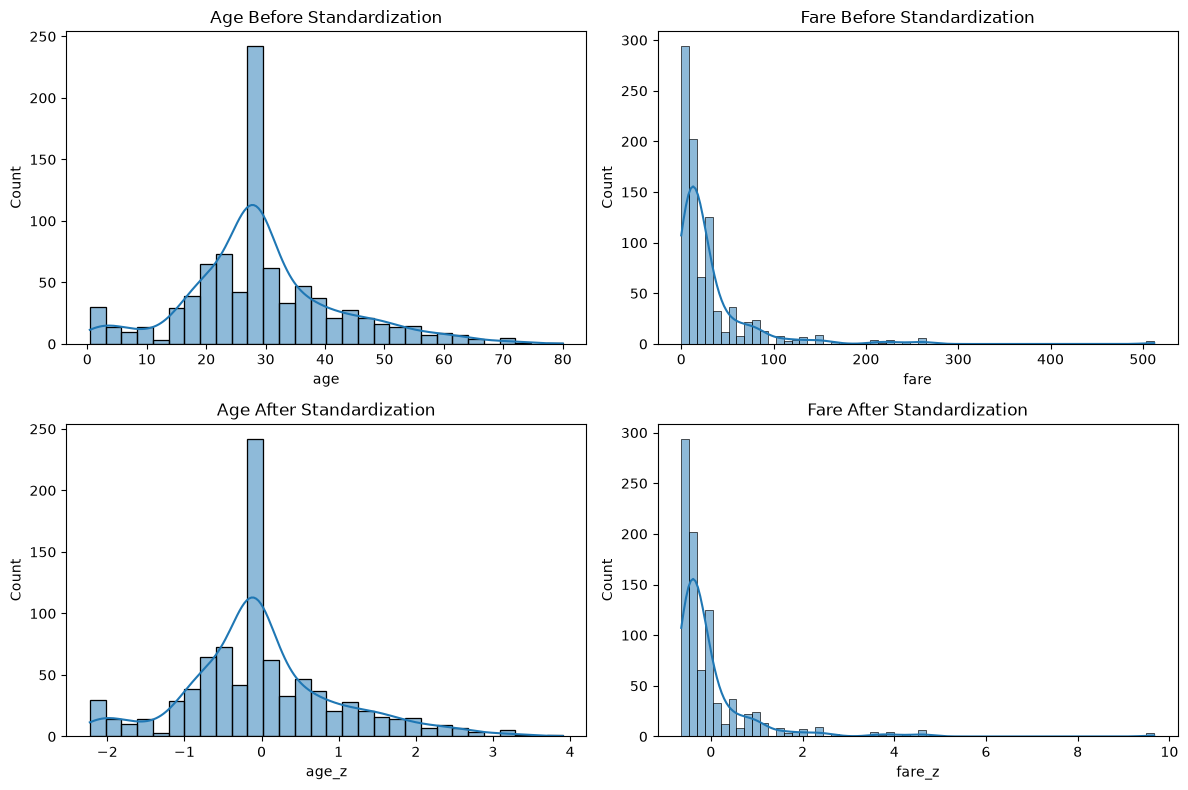

In [88]:
# Before and after plots distirbution


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Before
sns.histplot(df_titanic['age'], ax=axes[0,0], kde=True)
axes[0,0].set_title('Age Before Standardization')

sns.histplot(df_titanic['fare'], ax=axes[0,1], kde=True)
axes[0,1].set_title('Fare Before Standardization')

# After
sns.histplot(df_titanic['age_z'], ax=axes[1,0], kde=True)
axes[1,0].set_title('Age After Standardization')

sns.histplot(df_titanic['fare_z'], ax=axes[1,1], kde=True)
axes[1,1].set_title('Fare After Standardization')

plt.tight_layout()
plt.show()

**Interpretation**

As an exploratory preprocessing check, age and fare were standardized using the z-score formula z = (x − mean) / std. Before standardization, the variables had different scales, with fare showing much larger variability than age.

After standardization, both transformed variables have approximately mean 0 and standard deviation 1, confirming that the scaling was applied correctly. This step was performed only for EDA purposes and was not used in the predictive modeling pipeline, where scaling is applied separately on the training data after the train-test split to avoid data leakage.
`

converting the cleaned dataset to csv file for reading the modelling file

In [89]:
df_titanic.to_csv("titanic_cleaned.csv", index=False)
df_titanic.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    str     
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        889 non-null    category
 9   who          889 non-null    str     
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        889 non-null    str     
 13  alone        889 non-null    bool    
 14  age_z        889 non-null    float64 
 15  fare_z       889 non-null    float64 
dtypes: bool(2), category(1), float64(4), int64(4), str(5)
memory usage: 100.0 KB
